# Smart Energy Model — automatyczny raport wyników

**Autor:** Marta Gałuszka · **2026-08-11**

Jeden notebook = **raport końcowy**: wczytuje zapisane CSV, buduje Markdown, zapisuje plik.  
**Bez ponownego treningu** — to nie duplikat `04_prezentacja_kod.ipynb` (tam jest live `.fit()`).

| Notebook | Rola |
|----------|------|
| [`02_ML_predykcja_PV.ipynb`](02_ML_predykcja_PV.ipynb) | pełny research |
| [`04_prezentacja_kod.ipynb`](04_prezentacja_kod.ipynb) | demo kodu pipeline |
| **Ten plik (`05`)** | raport Markdown z artefaktów |
| [`03_prezentacja_dyplomowa.ipynb`](03_prezentacja_dyplomowa.ipynb) | slajdy obrony |

> **Regresja PV** — metryki: MAE, R², gap (nie accuracy / F1 / confusion matrix).


In [1]:
# 0) Setup
from pathlib import Path
import os
import json
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.rcParams['figure.figsize'] = (10, 4)
%matplotlib inline

def _find_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, here.parent):
        if (cand / 'src').is_dir() and (cand / 'docs').is_dir():
            return cand
    return here.parent if here.name == 'notebooks' else here

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

DATA = ROOT / 'data' / 'processed'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
FORECASTS = DATA / 'forecasts'

def show_table(df):
    d = df.copy()
    for c in d.columns:
        if pd.api.types.is_float_dtype(d[c]):
            d[c] = d[c].map(lambda x: f'{x:.3f}' if pd.notna(x) else '')
    cols = [str(c) for c in d.columns]
    lines = ['| ' + ' | '.join(cols) + ' |', '| ' + ' | '.join(['---'] * len(cols)) + ' |']
    for _, row in d.iterrows():
        lines.append('| ' + ' | '.join(str(v) for v in row.tolist()) + ' |')
    display(Markdown('\n'.join(lines)))

print('ROOT:', ROOT)


ROOT: /path/to/smart-energy-model


## 1. Konfiguracja eksperymentu (z treningu produkcyjnego)


In [2]:
summary_path = DATA / 'hourly_model_tuning_summary_production.csv'
if not summary_path.exists():
    raise FileNotFoundError(f'Brak {summary_path} — uruchom: python scripts/train/train_hourly_model_tuning.py')

prod = pd.read_csv(summary_path).iloc[0]
config = {
    'project': 'Smart Energy Model — prognoza PV',
    'random_state': int(prod.get('split_random_state', 42)),
    'test_split': '80/20 po dniach',
    'train_start': prod.get('train_start', ''),
    'train_end': prod.get('train_end', ''),
    'n_features': int(prod.get('n_features', 16)),
    'target': 'delta PVEnergyTotal (kWh/h)',
    'model_saved_at': '',
}
meta_path = ROOT / 'models' / 'pv_hourly_model.metadata.json'
if meta_path.exists():
    _meta = json.loads(meta_path.read_text(encoding='utf-8'))
    config['model_saved_at'] = (_meta.get('saved_at') or '')[:10]
    config['train_end'] = _meta.get('train_end', config['train_end'])

cfg_df = pd.DataFrame([
    {'parametr': 'Random state', 'wartość': config['random_state']},
    {'parametr': 'Split', 'wartość': config['test_split']},
    {'parametr': 'Okno treningowe', 'wartość': f"{config['train_start']} → {config['train_end']}"},
    {'parametr': 'Cechy produkcyjne', 'wartość': config['n_features']},
    {'parametr': 'Target', 'wartość': config['target']},
    {'parametr': 'Model .joblib (weekly)', 'wartość': config['model_saved_at'] or '—'},
])
show_table(cfg_df)


| parametr | wartość |
| --- | --- |
| Random state | 42 |
| Split | 80/20 po dniach |
| Okno treningowe | 2025-06-01 → 2026-08-15 |
| Cechy produkcyjne | 16 |
| Target | delta PVEnergyTotal (kWh/h) |
| Model .joblib (weekly) | 2026-08-16 |

## 2. Porównanie algorytmów (Ridge / RF / XGBoost)

Źródło: `scripts/analysis/compare_algorithms_hourly.py` → `hourly_algorithm_comparison.csv`


In [3]:
algo_path = DATA / 'hourly_algorithm_comparison.csv'
if not algo_path.exists():
    print('Brak CSV — wygeneruj: python scripts/analysis/compare_algorithms_hourly.py')
    algorithms = pd.DataFrame()
else:
    algorithms = pd.read_csv(algo_path)
    cols = ['label', 'test_mae_hour', 'test_r2_hour', 'gap_hour', 'daily_mae', 'verdict']
    cols = [c for c in cols if c in algorithms.columns]
    show_table(algorithms[cols].rename(columns={
        'label': 'Model',
        'test_mae_hour': 'Test MAE [kWh/h]',
        'test_r2_hour': 'Test R²',
        'gap_hour': 'Gap [kWh/h]',
        'daily_mae': 'Daily MAE [kWh/d]',
        'verdict': 'Werdykt',
    }))


| Model | Test MAE [kWh/h] | Test R² | Gap [kWh/h] | Daily MAE [kWh/d] | Werdykt |
| --- | --- | --- | --- | --- | --- |
| Ridge | 0.831 | 0.526 | -0.003 | 3.847 | ✅ Nie przeuczony |
| RF (prod.) | 0.602 | 0.675 | 0.096 | 3.780 | ✅ Nie przeuczony |
| XGBoost | 0.614 | 0.654 | 0.470 | 4.246 | ❌ Przeuczony |

## 3. Funkcja `generate_report()` — raport Markdown


In [4]:
def generate_report(project_name, config, algorithms_df, prod_row, ablation_df=None,
                    live_summary=None, live_tail=None, fi_top=None, val_end='—'):
    ts = datetime.now().strftime('%Y-%m-%d %H:%M')
    lines = [
        f'# Raport: {project_name}',
        f'**Data:** {ts}',
        '',
        '## Konfiguracja',
        f"- Random state: {config.get('random_state', 42)}",
        f"- Split: {config.get('test_split', '80/20 po dniach')}",
        f"- Okno treningowe: {config.get('train_start')} → {config.get('train_end')}",
        f"- Cechy: {config.get('n_features', 16)} · target: {config.get('target', 'PVE kWh/h')}",
        f"- Model weekly: {config.get('model_saved_at', '—')}",
        '',
        '## Wyniki modeli (holdout godzinowy)',
        '',
        '| Model | Test MAE [kWh/h] | Test R² | Gap [kWh/h] | Werdykt |',
        '|-------|----------------:|--------:|------------:|---------|',
    ]
    if algorithms_df is not None and len(algorithms_df):
        for _, r in algorithms_df.iterrows():
            label = r.get('label', r.get('model', '?'))
            lines.append(
                f"| {label} | {r['test_mae_hour']:.3f} | {r['test_r2_hour']:.3f} "
                f"| {r['gap_hour']:.3f} | {r.get('verdict', '')} |"
            )
    else:
        lines.append('| — | brak CSV | — | — | uruchom compare_algorithms_hourly |')

    if prod_row is not None:
        tmae = prod_row.get('test_mae_hour', prod_row.get('test_mae'))
        tr2 = prod_row.get('test_r2_hour', prod_row.get('test_r2'))
        lines.extend([
            '',
            '## Model produkcyjny (Random Forest 16)',
            f"- Test MAE: **{float(tmae):.3f}** kWh/h (holdout 80/20, weekly {config.get('model_saved_at', '—')})",
            f"- Test R²: **{float(tr2):.3f}**",
            f"- Gap train–test: **{float(prod_row['gap']):.3f}** kWh/h ({prod_row.get('verdict', '')})",
            f"- Daily MAE: **{float(prod_row['daily_mae']):.2f}** kWh/d",
        ])

    if algorithms_df is not None and len(algorithms_df):
        best = algorithms_df.sort_values('test_mae_hour').iloc[0]
        lines.extend([
            '',
            f"## Najlepszy algorytm (offline Test MAE): **{best['label']}**",
            f"- Test MAE: {best['test_mae_hour']:.3f} kWh/h · Test R²: {best['test_r2_hour']:.3f}",
            '- Uwaga: w produkcji RF 16 (kompromis MAE + gap + interpretowalność).',
        ])

    if ablation_df is not None and len(ablation_df):
        lines.extend(['', '## Ablacja cech (skrót)', ''])
        for _, r in ablation_df.iterrows():
            etap = r.get('Etap', r.iloc[0])
            n = r.get('N_cech', r.get('n_features', ''))
            mae = r.get('Test_MAE', r.get('test_mae', ''))
            lines.append(f"- {etap}: {n} cech, Test MAE = {float(mae):.3f} kWh/h")

    if live_summary is not None:
        lines.extend(['', f'## Walidacja operacyjna (closeout vs FoxESS, do {val_end})', ''])
        lines.append('| Okres | n | MAPE raw 5:00 | MAPE raw 12:00 | MAPE CS4 |')
        lines.append('|---|---:|---:|---:|---:|')
        for row in live_summary:
            cs4 = row.get('MAPE_CS4_%', np.nan)
            n_cs4 = row.get('n_cs4')
            cs4s = f"{cs4:.1f}% (n={n_cs4})" if pd.notna(cs4) and n_cs4 else (f'{cs4:.1f}%' if pd.notna(cs4) else '—')
            lines.append(
                f"| {row['okres']} | {row['n_dni']} | {row['MAPE_raw_5_%']:.1f}% | "
                f"{row['MAPE_raw_12_%']:.1f}% | {cs4s} |"
            )

    if live_tail is not None and len(live_tail):
        lines.extend(['', '## Ostatnie dni live (closeout)', ''])
        cols = list(live_tail.columns)
        lines.append('| ' + ' | '.join(cols) + ' |')
        lines.append('| ' + ' | '.join(['---'] * len(cols)) + ' |')
        for _, row in live_tail.iterrows():
            lines.append('| ' + ' | '.join(str(row[c]) for c in cols) + ' |')

    if fi_top is not None and len(fi_top):
        lines.extend(['', '## Feature importance (Top 5)', ''])
        for _, r in fi_top.head(5).iterrows():
            lines.append(f"- {r['feature']}: {r['importance']:.3f}")

    lines.extend([
        '',
        '## Wnioski',
        '- Prognoza godzinowa PV w skali FoxESS (target PVE).',
        '- Random Forest 16 cech: najlepszy kompromis offline MAE i niski gap.',
        f'- Live closeout do {val_end}: era dual MAPE raw ~9,1% / 9,7% (n=24).',
        '',
        '## Green IT',
        '- RF 200 drzew × 16 cech vs cięższy XGBoost — mniejsze ryzyko przeuczenia.',
        '- Harmonogram launchd (sync/prognoza/closeout) zamiast ciągłego retreningu w chmurze.',
        '',
        '---',
        f"*Wygenerowano z notebooka `05_raport_wynikow.ipynb`*",
    ])
    return '\n'.join(lines)

print('generate_report() — gotowe')


generate_report() — gotowe


## 4. Zbierz dane raportu i wyświetl


In [5]:
abl_path = DATA / 'ablation_results.csv'
ablation = pd.read_csv(abl_path) if abl_path.exists() else None

fi_path = DATA / 'hourly_feature_importance.csv'
fi = pd.read_csv(fi_path).sort_values('importance', ascending=False) if fi_path.exists() else None

# Metryki produkcyjne — preferuj metadata weekly (09.08) nad CSV tuningu
meta_path = ROOT / 'models' / 'pv_hourly_model.metadata.json'
if meta_path.exists():
    _meta = json.loads(meta_path.read_text(encoding='utf-8'))
    _met = _meta.get('metrics', {})
    prod['test_mae_hour'] = _met.get('test_mae', prod.get('test_mae_hour'))
    prod['test_r2_hour'] = prod.get('test_r2_hour', prod.get('test_r2'))
    prod['gap'] = _met.get('gap', prod.get('gap'))
    prod['daily_mae'] = _met.get('daily_mae', prod.get('daily_mae'))
    prod['verdict'] = _met.get('verdict', prod.get('verdict', ''))
    config['model_saved_at'] = (_meta.get('saved_at') or '')[:10]
    config['train_end'] = _meta.get('train_end', config.get('train_end'))

live_summary = None
live_tail = None
val_end = '—'
val_path = FORECASTS / 'forecast_validation.csv'
if val_path.exists():
    val = pd.read_csv(val_path)
    if 'closeout_at' in val.columns:
        val['closeout_at'] = pd.to_datetime(val['closeout_at'])
        val = val.sort_values('closeout_at').groupby('target_day', as_index=False).last()
    val['target_day'] = pd.to_datetime(val['target_day'])
    sub = val.dropna(subset=['actual_pv_report', 'predicted_daily_raw']).copy()
    sub = sub[sub['actual_pv_report'] > 0.5]
    sub['ape_raw_5'] = (sub['predicted_daily_raw'] - sub['actual_pv_report']).abs() / sub['actual_pv_report'] * 100
    sub['ape_raw_12'] = (sub['predicted_midday_raw'] - sub['actual_pv_report']).abs() / sub['actual_pv_report'] * 100
    if 'predicted_daily_cs4' in sub.columns:
        sub['ape_cs4'] = (sub['predicted_daily_cs4'] - sub['actual_pv_report']).abs() / sub['actual_pv_report'] * 100
    era = sub[sub['target_day'] >= '2026-07-27']
    all_ = sub[sub['target_day'] >= '2026-07-14']
    val_end = sub['target_day'].max().strftime('%d.%m.%Y')
    live_summary = [
        {'okres': f'Era dual 27.07–{sub["target_day"].max():%d.%m}', 'n_dni': len(era),
         'MAPE_raw_5_%': era['ape_raw_5'].mean(), 'MAPE_raw_12_%': era['ape_raw_12'].mean(),
         'MAPE_CS4_%': era['ape_cs4'].mean() if 'ape_cs4' in era else np.nan, 'n_cs4': int(era['ape_cs4'].notna().sum()) if 'ape_cs4' in era else 0},
        {'okres': f'Całość 14.07–{sub["target_day"].max():%d.%m}', 'n_dni': len(all_),
         'MAPE_raw_5_%': all_['ape_raw_5'].mean(), 'MAPE_raw_12_%': all_['ape_raw_12'].mean(),
         'MAPE_CS4_%': all_['ape_cs4'].mean() if 'ape_cs4' in all_ else np.nan, 'n_cs4': int(all_['ape_cs4'].notna().sum()) if 'ape_cs4' in all_ else 0},
    ]
    show_table(pd.DataFrame(live_summary).round(1))

    live_tail = sub.sort_values('target_day').tail(10).copy()
    live_tail['dzień'] = live_tail['target_day'].dt.strftime('%Y-%m-%d')
    live_tail['err_raw_kWh'] = (live_tail['predicted_daily_raw'] - live_tail['actual_pv_report']).round(2)
    cols = ['dzień', 'actual_pv_report', 'predicted_daily_raw', 'predicted_midday_raw', 'err_raw_kWh', 'ape_raw_5']
    if 'predicted_daily_cs4' in live_tail.columns:
        cols.extend(['predicted_daily_cs4', 'ape_cs4'])
    live_tail = live_tail[cols].round(2).rename(columns={
        'actual_pv_report': 'actual_kWh', 'predicted_daily_raw': 'raw_5:00',
        'predicted_midday_raw': 'raw_12:00', 'predicted_daily_cs4': 'CS4_5:00',
        'ape_raw_5': 'APE_raw_%', 'ape_cs4': 'APE_CS4_%',
    })
    print(f'\nOstatnie 10 dni live (closeout, do {val_end}):')
    show_table(live_tail)

report_md = generate_report(
    config['project'], config, algorithms, prod,
    ablation_df=ablation, live_summary=live_summary, live_tail=live_tail, fi_top=fi,
    val_end=val_end,
)
display(Markdown(report_md))


| okres | n_dni | MAPE_raw_5_% | MAPE_raw_12_% | MAPE_CS4_% | n_cs4 |
| --- | --- | --- | --- | --- | --- |
| Era dual 27.07–19.08 | 24 | 9.100 | 9.700 | 10.000 | 24 |
| Całość 14.07–19.08 | 37 | 14.800 | 13.800 | 10.000 | 24 |


Ostatnie 10 dni live (closeout, do 19.08.2026):


| dzień | actual_kWh | raw_5:00 | raw_12:00 | err_raw_kWh | APE_raw_% | CS4_5:00 | APE_CS4_% |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2026-08-10 | 28.900 | 30.570 | 26.060 | 1.670 | 5.780 | 29.630 | 2.530 |
| 2026-08-11 | 22.600 | 21.470 | 24.180 | -1.130 | 5.000 | 20.940 | 7.350 |
| 2026-08-12 | 36.300 | 32.250 | 32.600 | -4.050 | 11.160 | 31.240 | 13.940 |
| 2026-08-13 | 37.700 | 33.510 | 33.390 | -4.190 | 11.110 | 32.900 | 12.730 |
| 2026-08-14 | 37.300 | 33.500 | 33.540 | -3.800 | 10.190 | 33.290 | 10.750 |
| 2026-08-15 | 35.900 | 33.610 | 33.630 | -2.290 | 6.380 | 33.280 | 7.300 |
| 2026-08-16 | 33.700 | 32.720 | 32.260 | -0.980 | 2.910 | 33.250 | 1.340 |
| 2026-08-17 | 21.500 | 22.200 | 18.900 | 0.700 | 3.260 | 21.360 | 0.650 |
| 2026-08-18 | 17.800 | 20.260 | 20.260 | 2.460 | 13.820 | 19.330 | 8.600 |
| 2026-08-19 | 24.700 | 20.990 | 19.750 | -3.710 | 15.020 | 19.760 | 20.000 |

# Raport: Smart Energy Model — prognoza PV
**Data:** 2026-08-20 16:30

## Konfiguracja
- Random state: 42
- Split: 80/20 po dniach
- Okno treningowe: 2025-06-01 → 2026-08-15
- Cechy: 16 · target: delta PVEnergyTotal (kWh/h)
- Model weekly: 2026-08-16

## Wyniki modeli (holdout godzinowy)

| Model | Test MAE [kWh/h] | Test R² | Gap [kWh/h] | Werdykt |
|-------|----------------:|--------:|------------:|---------|
| Ridge | 0.831 | 0.526 | -0.003 | ✅ Nie przeuczony |
| RF (prod.) | 0.602 | 0.675 | 0.096 | ✅ Nie przeuczony |
| XGBoost | 0.614 | 0.654 | 0.470 | ❌ Przeuczony |

## Model produkcyjny (Random Forest 16)
- Test MAE: **0.643** kWh/h (holdout 80/20, weekly 2026-08-16)
- Test R²: **0.681**
- Gap train–test: **0.063** kWh/h (✅ Model NIE jest przeuczony)
- Daily MAE: **3.56** kWh/d

## Najlepszy algorytm (offline Test MAE): **RF (prod.)**
- Test MAE: 0.602 kWh/h · Test R²: 0.675
- Uwaga: w produkcji RF 16 (kompromis MAE + gap + interpretowalność).

## Ablacja cech (skrót)

- 1_Baza: 1 cech, Test MAE = 1.072 kWh/h
- 2_Pogoda: 6 cech, Test MAE = 0.622 kWh/h
- 3_Kalendarz: 9 cech, Test MAE = 0.605 kWh/h
- 3_Pogoda_Slonce: 13 cech, Test MAE = 0.580 kWh/h
- 3_Pogoda_Slonce_Reguly: 16 cech, Test MAE = 0.581 kWh/h
- 4_Reguly: 19 cech, Test MAE = 0.578 kWh/h

## Walidacja operacyjna (closeout vs FoxESS, do 19.08.2026)

| Okres | n | MAPE raw 5:00 | MAPE raw 12:00 | MAPE CS4 |
|---|---:|---:|---:|---:|
| Era dual 27.07–19.08 | 24 | 9.1% | 9.7% | 10.0% (n=24) |
| Całość 14.07–19.08 | 37 | 14.8% | 13.8% | 10.0% (n=24) |

## Ostatnie dni live (closeout)

| dzień | actual_kWh | raw_5:00 | raw_12:00 | err_raw_kWh | APE_raw_% | CS4_5:00 | APE_CS4_% |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2026-08-10 | 28.9 | 30.57 | 26.06 | 1.67 | 5.78 | 29.63 | 2.53 |
| 2026-08-11 | 22.6 | 21.47 | 24.18 | -1.13 | 5.0 | 20.94 | 7.35 |
| 2026-08-12 | 36.3 | 32.25 | 32.6 | -4.05 | 11.16 | 31.24 | 13.94 |
| 2026-08-13 | 37.7 | 33.51 | 33.39 | -4.19 | 11.11 | 32.9 | 12.73 |
| 2026-08-14 | 37.3 | 33.5 | 33.54 | -3.8 | 10.19 | 33.29 | 10.75 |
| 2026-08-15 | 35.9 | 33.61 | 33.63 | -2.29 | 6.38 | 33.28 | 7.3 |
| 2026-08-16 | 33.7 | 32.72 | 32.26 | -0.98 | 2.91 | 33.25 | 1.34 |
| 2026-08-17 | 21.5 | 22.2 | 18.9 | 0.7 | 3.26 | 21.36 | 0.65 |
| 2026-08-18 | 17.8 | 20.26 | 20.26 | 2.46 | 13.82 | 19.33 | 8.6 |
| 2026-08-19 | 24.7 | 20.99 | 19.75 | -3.71 | 15.02 | 19.76 | 20.0 |

## Feature importance (Top 5)

- radiation_wm2: 0.309
- hours_until_sunset: 0.177
- sun_position: 0.173
- cloud_cover_pct: 0.090
- temp_c: 0.081

## Wnioski
- Prognoza godzinowa PV w skali FoxESS (target PVE).
- Random Forest 16 cech: najlepszy kompromis offline MAE i niski gap.
- Live closeout do 19.08.2026: era dual MAPE raw ~9,1% / 9,7% (n=24).

## Green IT
- RF 200 drzew × 16 cech vs cięższy XGBoost — mniejsze ryzyko przeuczenia.
- Harmonogram launchd (sync/prognoza/closeout) zamiast ciągłego retreningu w chmurze.

---
*Wygenerowano z notebooka `05_raport_wynikow.ipynb`*

## 5. Zapis raportu do pliku


In [6]:
out_path = REPORTS / 'model_comparison.md'
REPORTS.mkdir(parents=True, exist_ok=True)
out_path.write_text(report_md + '\n', encoding='utf-8')
print('Zapisano:', out_path)
print('Rozmiar:', out_path.stat().st_size, 'bajtów')


Zapisano: /path/to/smart-energy-model/reports/model_comparison.md
Rozmiar: 3011 bajtów


## 6. Wykresy z raportu (zapisane artefakty)


In [7]:
from IPython.display import Image

chart_map = {
    'Porównanie algorytmów (holdout)': FIGURES / 'hourly_algorithm_comparison.png',
    'Scatter RF (holdout godzinowy)': FIGURES / 'hourly_algorithm_scatter.png',
    'Walidacja operacyjna (14.07→19.08)': FIGURES / 'production_validation_plot.png',
    'Walidacja lipiec + |APE|': FIGURES / 'july_validation_plot.png',
    'Holdout dzienny (train vs holdout)': FIGURES / 'production_validation.png',
}
gh_dir = ROOT / 'docs' / 'images' / 'ml'

for title, local in chart_map.items():
    path = local if local.exists() else gh_dir / local.name
    if path.exists():
        print(f'{title}: {path.name}')
        rel = f'../docs/images/ml/{path.name}'
        display(Markdown(f'<img src="{rel}" width="700" alt="{path.name}"/>'))
    else:
        print(f'Brak wykresu: {title} — uruchom scripts/analysis/refresh_notebook05_report.py')


Porównanie algorytmów (holdout): hourly_algorithm_comparison.png


<img src="../docs/images/ml/hourly_algorithm_comparison.png" width="700" alt="hourly_algorithm_comparison.png"/>

Scatter RF (holdout godzinowy): hourly_algorithm_scatter.png


<img src="../docs/images/ml/hourly_algorithm_scatter.png" width="700" alt="hourly_algorithm_scatter.png"/>

Walidacja operacyjna (14.07→19.08): production_validation_plot.png


<img src="../docs/images/ml/production_validation_plot.png" width="700" alt="production_validation_plot.png"/>

Walidacja lipiec + |APE|: july_validation_plot.png


<img src="../docs/images/ml/july_validation_plot.png" width="700" alt="july_validation_plot.png"/>

Holdout dzienny (train vs holdout): production_validation.png


<img src="../docs/images/ml/production_validation.png" width="700" alt="production_validation.png"/>

## 7. Feature importance (Top 10)


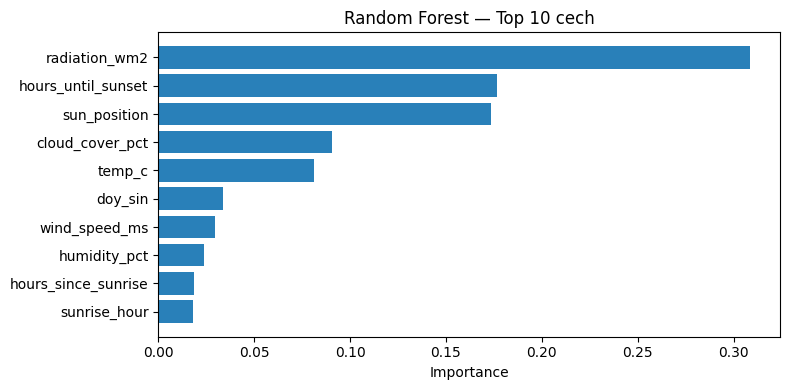

In [8]:
if fi is not None:
    top = fi.head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(top['feature'][::-1], top['importance'][::-1], color='#2980b9')
    ax.set_xlabel('Importance')
    ax.set_title('Random Forest — Top 10 cech')
    plt.tight_layout()
    plt.show()
else:
    print('Brak hourly_feature_importance.csv')


## 8. Podsumowanie

1. Raport Markdown z zapisanych CSV (metryki regresji: MAE / R² / gap, nie accuracy/F1).
2. Plik: [`reports/model_comparison.md`](../reports/model_comparison.md) — można commitować / pokazać na obronie.
3. Aktualny snapshot metryk: [`docs/STATUS_ML_MLOPS.md`](../docs/STATUS_ML_MLOPS.md).
4. Historia gate’ów: [`docs/CHANGELOG_ML.md`](../docs/CHANGELOG_ML.md) (`compare_model_change.py --append-changelog`).
